In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv("/content/Medical Insurance Dataset.csv")

In [12]:
df = df.drop("charger", axis=1)

In [13]:
df.describe()

,age,bmi,children,charges
count,3038.000000,3038.000000,3038.000000,3038.000000
mean,39.089862,30.700265,1.098749,13335.661423
std,14.121217,6.085241,1.215146,12209.554407
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.315000,0.000000,4676.641325
50%,39.000000,30.400000,1.000000,9391.346000
75%,51.000000,34.800000,2.000000,16862.795985
max,64.000000,53.130000,5.000000,63770.428010


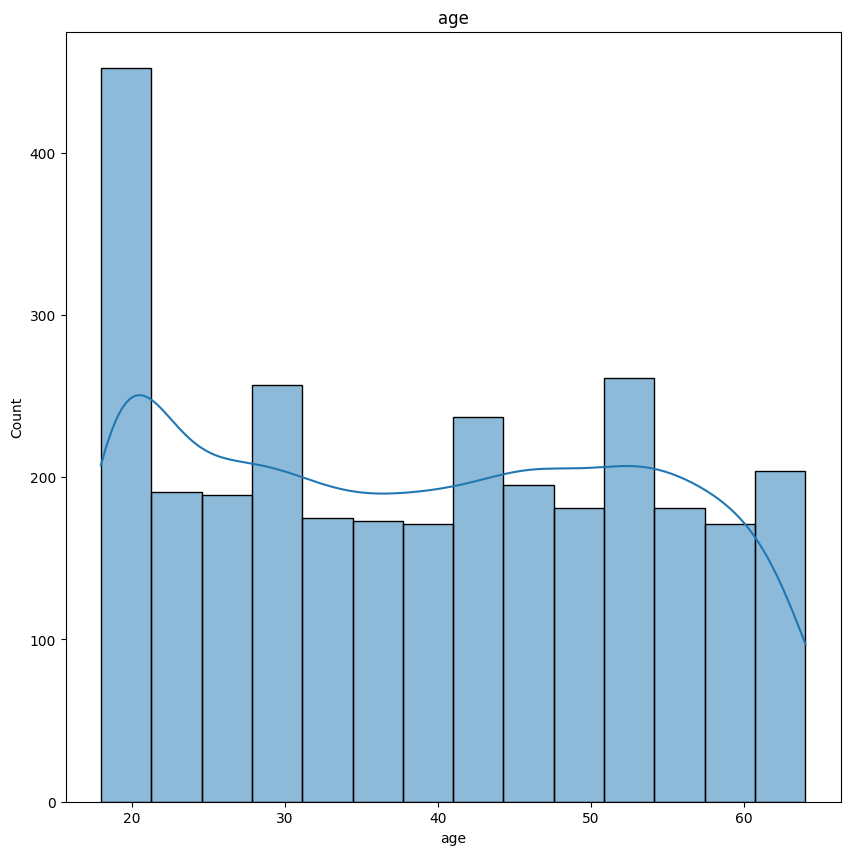

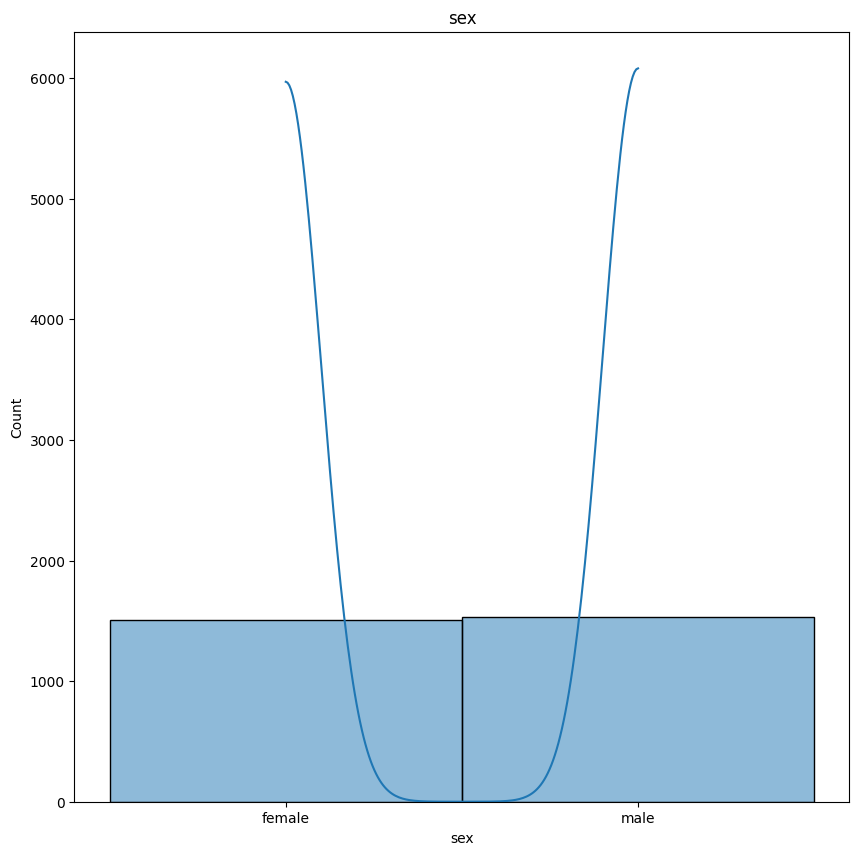

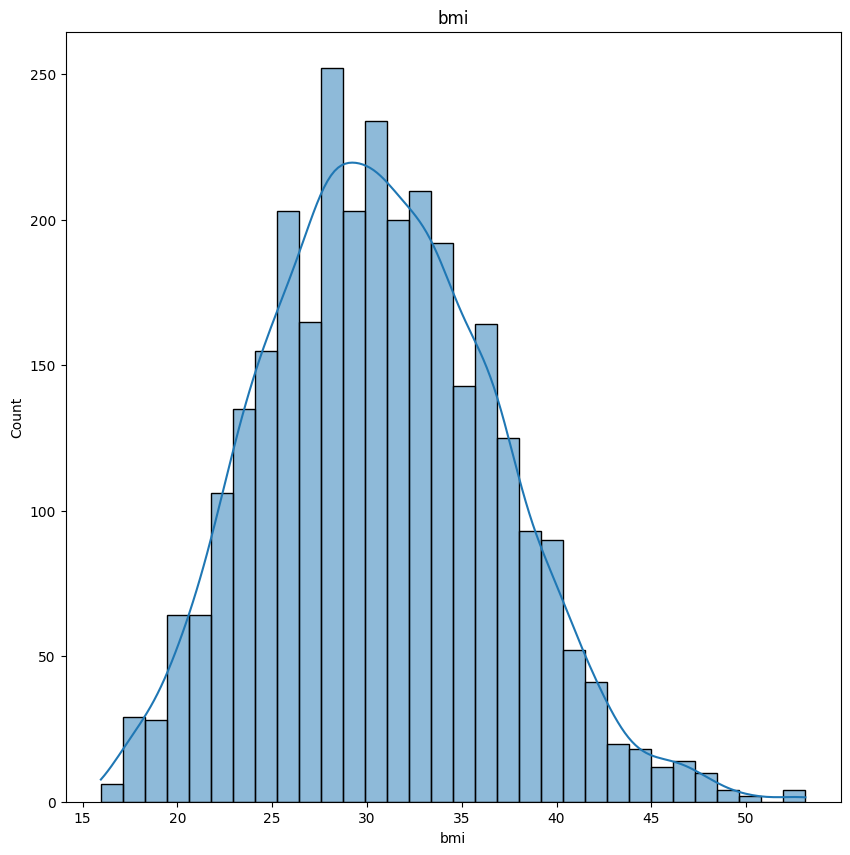

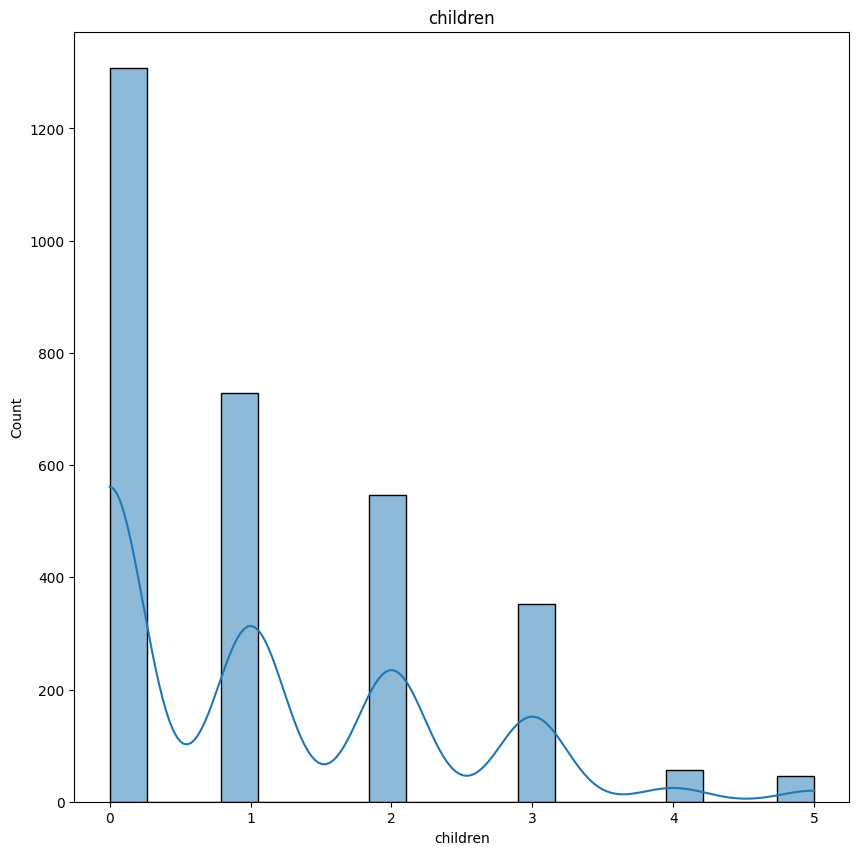

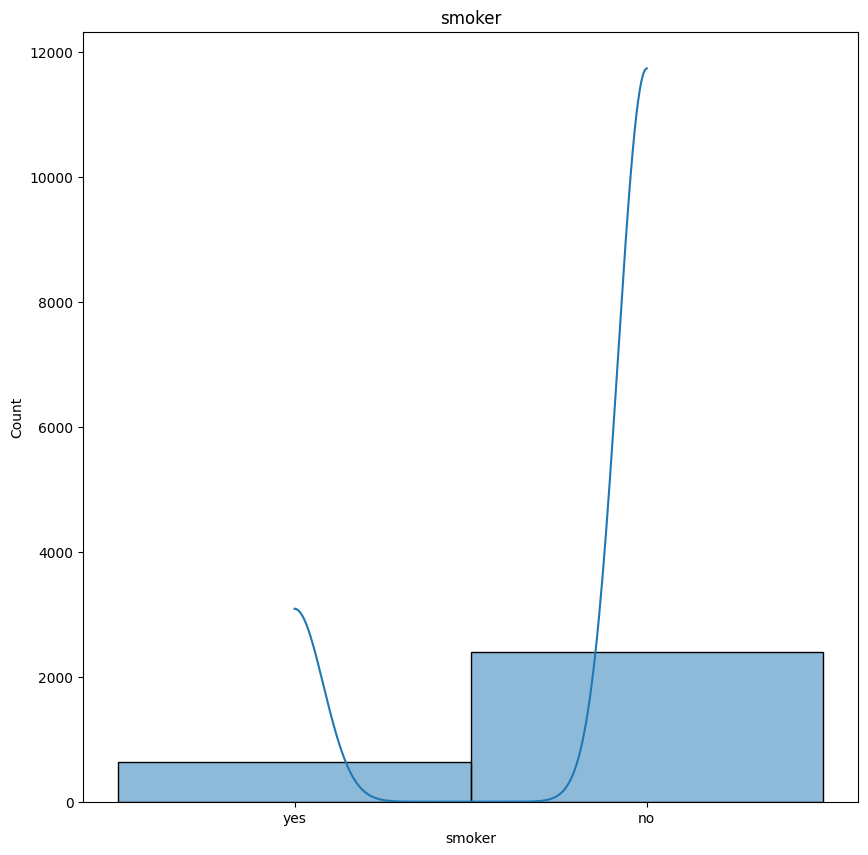

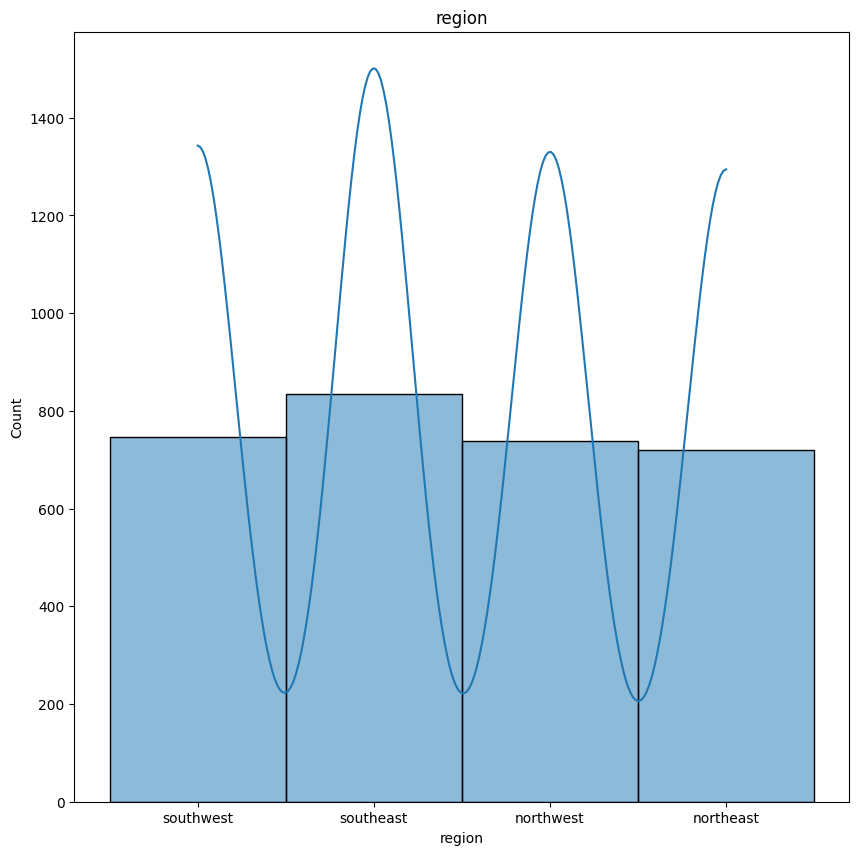

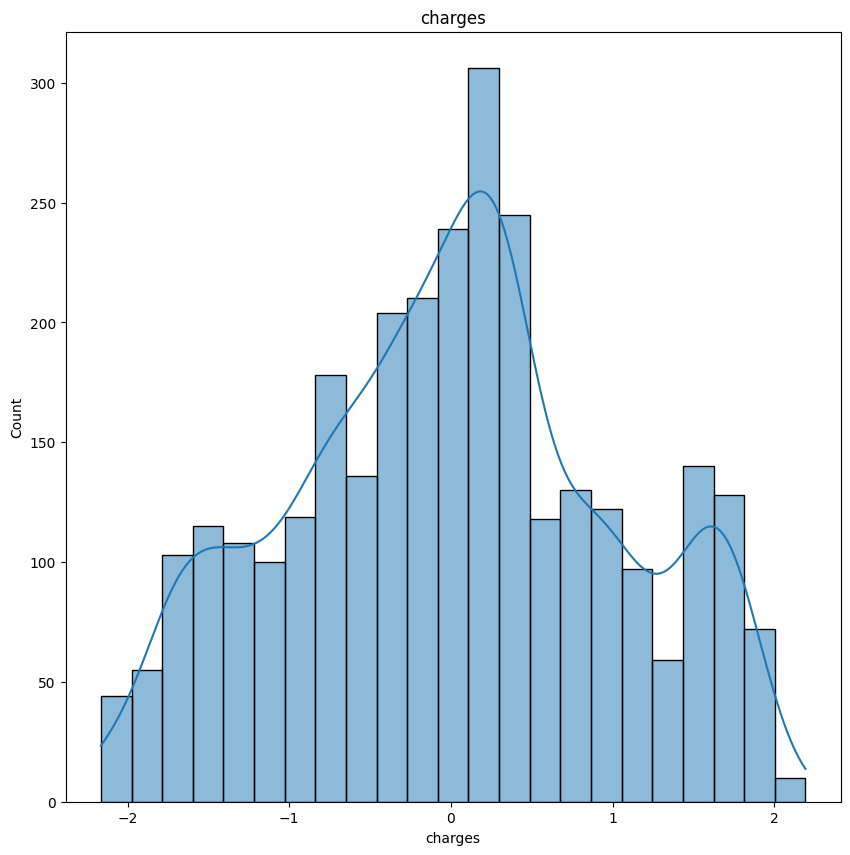

In [16]:
for i in df.columns:
   plt.figure(figsize=(10,10))
   sns.histplot(df[i],kde=True)
   plt.title(i)
   plt.show()


In [15]:
from sklearn.preprocessing import PowerTransformer
import numpy as np

# Fix: Replace infinity values (likely from the log(0) in the previous cell) with 0
df["charges"].replace([np.inf, -np.inf], 0, inplace=True)

pt = PowerTransformer(method='yeo-johnson')
# for i in df.columns:
   # Yeo-johnson can handle zero and negative values, but not infinity
df[["charges"]] = pt.fit_transform(df[["charges"]])

/tmp/ipykernel_736/1475534996.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["charges"].replace([np.inf, -np.inf], 0, inplace=True)


In [17]:
for i in df.columns:
  print(i,':','\n',df[i].unique(),'\n')

age : 
 [19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39] 

sex : 
 ['female' 'male'] 

bmi : 
 [27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.72  32.205 28.595 49.06  27.17  23.37  37.1
 23.75  28.975 31.35  33.915 28.785 28.3   

In [ ]:
df["charges"].unique()

array([ 9.73423565,  7.45388181,  8.40076319, ...,  7.39684651,
        7.60536499, 10.27994808])

In [18]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split


# 1. Separate features and target
X = df.drop("charges", axis=1)

y = (df["charges"])


# 2. Define features
numerical_features = ["age", "bmi", "children"]

categorical_features = ["sex", "smoker", "region"]


# 3. Numerical pipeline
numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])


# 4. Categorical pipeline
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# 5. Column Transformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])


# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 7. Preprocess X
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


# 8. Check shape
print(type(X_train))
print(X_train.shape)

<class 'numpy.ndarray'>
(2430, 11)


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Dense(64, input_dim=11, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='linear'))

model.compile(
    Adam(learning_rate=0.002),
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.fit(X_train,y_train,
          validation_data=(X_test,y_test),
          epochs=150, # Increased epochs from 100 to 200
          batch_size=32
          )

Epoch 1/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0356 - val_loss: 0.0980
Epoch 2/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0383 - val_loss: 0.0998
Epoch 3/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0331 - val_loss: 0.1024
Epoch 4/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0373 - val_loss: 0.1034
Epoch 5/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0502 - val_loss: 0.1162
Epoch 6/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0465 - val_loss: 0.1086
Epoch 7/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0420 - val_loss: 0.1151
Epoch 8/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0438 - val_loss: 0.1233
Epoch 9/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0406 - val_loss: 0.0987
Epoch 10/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0337 - val_loss: 0.1064
Epoch 11/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0344 - val_loss: 0.1053
Epoch 12/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0

In [27]:
pred = model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [28]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse = mean_squared_error(y_test,pred)
mae = mean_absolute_error(y_test,pred)
r2= r2_score(y_test,pred)

print('MSE:',mse)
print('MAE:',mae)
print('R2:',r2)


MSE: 0.09946878592597933
MAE: 0.13922409217489842
R2: 0.900904342807717


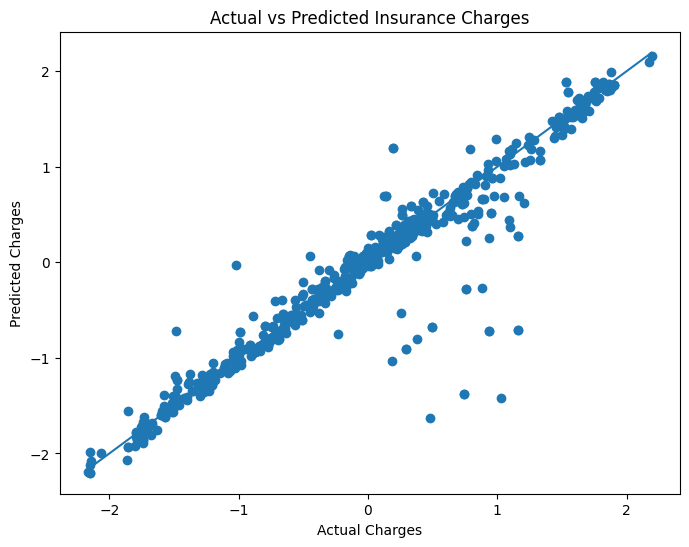

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()

In [30]:
import pandas as pd

# Prediction from model (transformed scale)
pred = model.predict(X_test)

# Convert predictions back to original charges
pred_actual = pt.inverse_transform(pred).flatten()

# Convert y_test back to original charges
actual = pt.inverse_transform(
    y_test.values.reshape(-1, 1)
).flatten()

# Actual vs Predicted
comparison = pd.DataFrame({
    "Actual Charges": actual,
    "Predicted Charges": pred_actual
})

print(comparison.head(10))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
   Actual Charges  Predicted Charges
0     13822.80300       12187.519531
1      6358.77645        6890.119629
2     28287.89766       24109.242188
3      7160.09400        7073.738770
4     18157.87600       11221.422852
5     17179.52200       17834.570312
6      5708.86700        6659.106445
7     13019.16105       12813.842773
8     21344.84670        4631.249023
9     13470.80440       16143.739258


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2

)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Dense(64, input_dim=11, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='linear'))

model.compile(
    Adam(learning_rate=0.002),
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

model.fit(X_train_processed,y_train,
          validation_data=(X_test_processed,y_test),
          epochs=150, # Increased epochs from 100 to 200
          batch_size=32
          )
prdicted = model.predict(X_test_processed)
print(prdicted)


Epoch 1/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0429 - val_loss: 0.0888
Epoch 2/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0446 - val_loss: 0.0940
Epoch 3/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0416 - val_loss: 0.0828
Epoch 4/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0428 - val_loss: 0.0890
Epoch 5/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0466 - val_loss: 0.0876
Epoch 6/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0449 - val_loss: 0.0897
Epoch 7/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0429 - val_loss: 0.0831
Epoch 8/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0408 - val_loss: 0.0838
Epoch 9/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0453 - val_loss: 0.0859
Epoch 10/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0434 - val_loss: 0.0924
Epoch 11/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0427 - val_loss: 0.0851
Epoch 12/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss

In [42]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse = mean_squared_error(y_test,prdicted)
mae = mean_absolute_error(y_test,prdicted)
r2= r2_score(y_test,prdicted)

print('MSE:',mse)
print('MAE:',mae)
print('R2:',r2)


MSE: 0.06443331204763933
MAE: 0.1172092518864477
R2: 0.9328538630021054


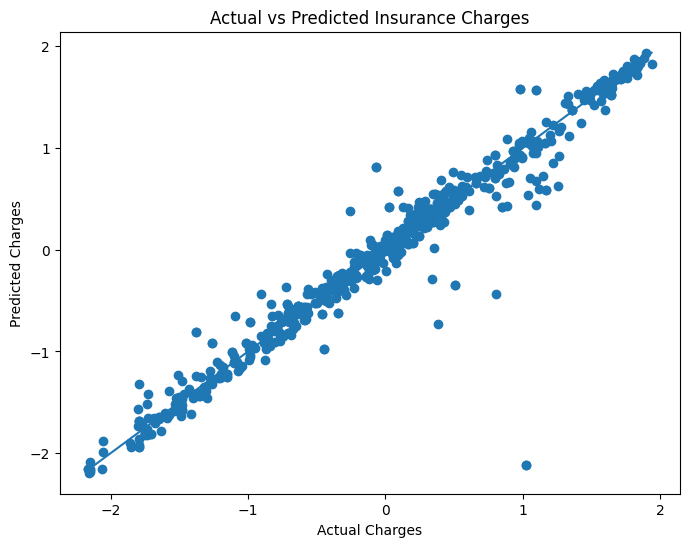

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, prdicted)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()